# Notebook 6: Model Explainability & Calibration

**Site Revenue Prediction ML System - SageMaker Notebook Series**

This notebook covers:
- Probability calibration (for classification tasks)
- Conformal prediction with coverage guarantees
- SHAP feature importance analysis
- Business tier classification
- Executive-friendly interpretations

## SageMaker Notes
- SHAP computations can be parallelized across SageMaker instances
- Calibration artifacts should be saved alongside the model
- Recommended instance: `ml.m5.xlarge` for SHAP analysis

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import pickle
import warnings

# Check for optional dependencies
try:
    import shap
    SHAP_AVAILABLE = True
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Install with: pip install shap")

from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
from sklearn.base import BaseEstimator, ClassifierMixin

plt.style.use('seaborn-v0_8-whitegrid')

print(f"PyTorch version: {torch.__version__}")

SHAP version: 0.50.0
PyTorch version: 2.9.1


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Model and Data

In [ ]:
OUTPUT_DIR = Path('./outputs')

# Device selection
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

In [3]:
# Model architecture (copy from previous notebooks)
class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.2):
        super().__init__()
        self.linear1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.linear2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout)
        self.projection = nn.Linear(in_features, out_features) if in_features != out_features else nn.Identity()
    
    def forward(self, x):
        residual = self.projection(x)
        out = torch.relu(self.bn1(self.linear1(x)))
        out = self.dropout(out)
        out = self.bn2(self.linear2(out))
        return torch.relu(out + residual)

class CategoricalEmbedding(nn.Module):
    def __init__(self, vocab_sizes, embedding_dim=16):
        super().__init__()
        self.embeddings = nn.ModuleDict()
        self.feature_names = list(vocab_sizes.keys())
        for name, vocab_size in vocab_sizes.items():
            dim = min(embedding_dim, max(4, (vocab_size + 1) // 2))
            self.embeddings[name] = nn.Embedding(vocab_size + 1, dim, padding_idx=0)
        self.output_dim = sum(self.embeddings[name].embedding_dim for name in self.feature_names)
    
    def forward(self, x):
        embeddings = []
        for i, name in enumerate(self.feature_names):
            idx = x[:, i].clamp(0, self.embeddings[name].num_embeddings - 1)
            embeddings.append(self.embeddings[name](idx))
        return torch.cat(embeddings, dim=1)

class SiteScoringModel(nn.Module):
    def __init__(self, n_numeric, n_boolean, categorical_vocab_sizes, embedding_dim=16, hidden_dims=None, dropout=0.2):
        super().__init__()
        hidden_dims = hidden_dims or [512, 256, 128, 64]
        self.cat_embedding = CategoricalEmbedding(categorical_vocab_sizes, embedding_dim)
        self.numeric_bn = nn.BatchNorm1d(n_numeric) if n_numeric > 0 else None
        self.n_numeric = n_numeric
        self.n_boolean = n_boolean
        total_input_dim = self.cat_embedding.output_dim + n_numeric + n_boolean
        layers = []
        in_dim = total_input_dim
        for out_dim in hidden_dims:
            layers.append(ResidualBlock(in_dim, out_dim, dropout))
            in_dim = out_dim
        self.mlp = nn.Sequential(*layers)
        self.output = nn.Linear(hidden_dims[-1], 1)
    
    def forward(self, numeric, categorical, boolean):
        cat_embedded = self.cat_embedding(categorical)
        if self.numeric_bn is not None and self.n_numeric > 0:
            numeric = self.numeric_bn(numeric)
        x = torch.cat([cat_embedded, numeric, boolean], dim=1)
        x = self.mlp(x)
        return self.output(x)

In [4]:
# Load model
checkpoint = torch.load(OUTPUT_DIR / 'best_model.pt', map_location=device, weights_only=False)
config = checkpoint['config']

model = SiteScoringModel(
    n_numeric=config['n_numeric'],
    n_boolean=config['n_boolean'],
    categorical_vocab_sizes=config['categorical_vocab_sizes'],
    embedding_dim=config['embedding_dim'],
    hidden_dims=config['hidden_dims'],
    dropout=config['dropout'],
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"Model loaded on {device}")

Model loaded on mps


In [5]:
# Load preprocessor and data
with open(OUTPUT_DIR / 'preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

data = torch.load(OUTPUT_DIR / 'processed_data.pt', weights_only=False)

numeric = data['numeric']
categorical = data['categorical']
boolean = data['boolean']
target = data['target']
val_idx = data['val_idx']
test_idx = data['test_idx']

print(f"Validation set: {len(val_idx):,}, Test set: {len(test_idx):,}")

Validation set: 3,413, Test set: 3,414


## 2. Sklearn Model Wrapper

SHAP and other sklearn tools expect a standard sklearn interface. This wrapper provides it.

In [6]:
class SklearnModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps PyTorch model to provide sklearn-compatible interface.
    Used for SHAP, calibration, and other sklearn tools.
    """
    
    def __init__(self, model, n_numeric, n_categorical, n_boolean, device='cpu'):
        self.model = model
        self.n_numeric = n_numeric
        self.n_categorical = n_categorical
        self.n_boolean = n_boolean
        self.device = device
        self.classes_ = np.array([0, 1])  # Binary classification
    
    def _split_features(self, X):
        """Split concatenated features back into numeric, categorical, boolean."""
        X = np.asarray(X)
        cat_start = self.n_numeric
        bool_start = cat_start + self.n_categorical
        
        numeric = X[:, :cat_start].astype(np.float32)
        categorical = X[:, cat_start:bool_start].astype(np.int64)
        boolean = X[:, bool_start:].astype(np.float32)
        
        return (
            torch.from_numpy(numeric).to(self.device),
            torch.from_numpy(categorical).to(self.device),
            torch.from_numpy(boolean).to(self.device),
        )
    
    def fit(self, X, y):
        """No-op: model is already trained."""
        return self
    
    def predict(self, X):
        """Predict class labels (for classification)."""
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)
    
    def predict_proba(self, X):
        """
        Predict class probabilities.
        Returns array of shape (n_samples, 2) with [P(class=0), P(class=1)].
        """
        self.model.eval()
        numeric, categorical, boolean = self._split_features(X)
        
        with torch.no_grad():
            logits = self.model(numeric, categorical, boolean)
            proba_1 = torch.sigmoid(logits).cpu().numpy().ravel()
        
        proba_0 = 1 - proba_1
        return np.column_stack([proba_0, proba_1])
    
    def predict_regression(self, X):
        """
        Predict continuous values (for regression).
        Returns raw model output.
        """
        self.model.eval()
        numeric, categorical, boolean = self._split_features(X)
        
        with torch.no_grad():
            predictions = self.model(numeric, categorical, boolean)
        
        return predictions.cpu().numpy().ravel()

# Create wrapper
n_categorical = len(config['categorical_vocab_sizes'])
sklearn_wrapper = SklearnModelWrapper(
    model=model,
    n_numeric=config['n_numeric'],
    n_categorical=n_categorical,
    n_boolean=config['n_boolean'],
    device=device,
)

print(f"Sklearn wrapper created with:")
print(f"  Numeric features: {config['n_numeric']}")
print(f"  Categorical features: {n_categorical}")
print(f"  Boolean features: {config['n_boolean']}")

Sklearn wrapper created with:
  Numeric features: 11
  Categorical features: 9
  Boolean features: 40


## 3. Probability Calibration (For Classification)

Calibration ensures predicted probabilities match observed frequencies. When the model outputs 75% confidence, calibration ensures ~75% of similar predictions were actually correct.

In [7]:
class ProbabilityCalibrator:
    """
    Calibrates model probability outputs to match true frequencies.
    Uses isotonic regression for flexible, non-parametric calibration.
    """
    
    def __init__(self, method='isotonic'):
        self.method = method
        self.calibrator = IsotonicRegression(out_of_bounds='clip')
        self._fitted = False
        self.brier_score_before = None
        self.brier_score_after = None
    
    def fit(self, y_proba, y_true):
        """Fit calibrator on held-out calibration data."""
        y_proba = np.asarray(y_proba).ravel()
        y_true = np.asarray(y_true).ravel()
        
        self.brier_score_before = brier_score_loss(y_true, y_proba)
        self.calibrator.fit(y_proba, y_true)
        self._fitted = True
        
        y_calibrated = self.calibrate(y_proba)
        self.brier_score_after = brier_score_loss(y_true, y_calibrated)
        
        return self
    
    def calibrate(self, y_proba):
        """Transform raw probabilities to calibrated probabilities."""
        if not self._fitted:
            raise RuntimeError("Calibrator not fitted. Call fit() first.")
        y_proba = np.asarray(y_proba).ravel()
        calibrated = self.calibrator.predict(y_proba)
        return np.clip(calibrated, 0, 1)
    
    def get_reliability_data(self, y_proba, y_true, n_bins=10):
        """Compute data for reliability diagram."""
        y_proba = np.asarray(y_proba).ravel()
        y_true = np.asarray(y_true).ravel()
        
        bins = np.linspace(0, 1, n_bins + 1)
        bin_indices = np.digitize(y_proba, bins[1:-1])
        
        bin_means = []
        observed_freqs = []
        bin_counts = []
        
        for i in range(n_bins):
            mask = bin_indices == i
            if mask.sum() > 0:
                bin_means.append(y_proba[mask].mean())
                observed_freqs.append(y_true[mask].mean())
                bin_counts.append(mask.sum())
            else:
                bin_means.append(np.nan)
                observed_freqs.append(np.nan)
                bin_counts.append(0)
        
        return np.array(bin_means), np.array(observed_freqs), np.array(bin_counts)

print("ProbabilityCalibrator class defined")

ProbabilityCalibrator class defined


In [8]:
# For classification tasks, demonstrate calibration
# First, create binary classification targets (top 10% performers)

# Get validation data
val_numeric = numeric[val_idx]
val_categorical = categorical[val_idx]
val_boolean = boolean[val_idx]
val_target = target[val_idx]

# Concatenate features for sklearn wrapper
val_X = np.concatenate([
    val_numeric.numpy(),
    val_categorical.numpy(),
    val_boolean.numpy(),
], axis=1)

# Create binary labels (top 10% for classification demo)
# For regression, we'll convert predictions to a "high revenue" probability
target_scaler = preprocessor['target_scaler']
if target_scaler is not None:
    val_target_orig = target_scaler.inverse_transform(val_target.numpy()).flatten()
else:
    val_target_orig = val_target.numpy().flatten()

# Define "high revenue" as top 10%
threshold_90 = np.percentile(val_target_orig, 90)
val_binary = (val_target_orig >= threshold_90).astype(int)

print(f"Calibration data:")
print(f"  Validation samples: {len(val_X):,}")
print(f"  High revenue threshold (90th percentile): ${threshold_90:,.0f}")
print(f"  Positive class (high revenue): {val_binary.sum():,} ({val_binary.mean()*100:.1f}%)")

Calibration data:
  Validation samples: 3,413
  High revenue threshold (90th percentile): $638
  Positive class (high revenue): 342 (10.0%)


In [9]:
# Get raw probabilities
raw_proba = sklearn_wrapper.predict_proba(val_X)[:, 1]

# Fit calibrator
calibrator = ProbabilityCalibrator(method='isotonic')
calibrator.fit(raw_proba, val_binary)

# Get calibrated probabilities
calibrated_proba = calibrator.calibrate(raw_proba)

print(f"\nCalibration Results:")
print(f"  Brier score before: {calibrator.brier_score_before:.4f}")
print(f"  Brier score after:  {calibrator.brier_score_after:.4f}")
print(f"  Improvement: {(calibrator.brier_score_before - calibrator.brier_score_after) / calibrator.brier_score_before * 100:.1f}%")


Calibration Results:
  Brier score before: 0.1795
  Brier score after:  0.0280
  Improvement: 84.4%


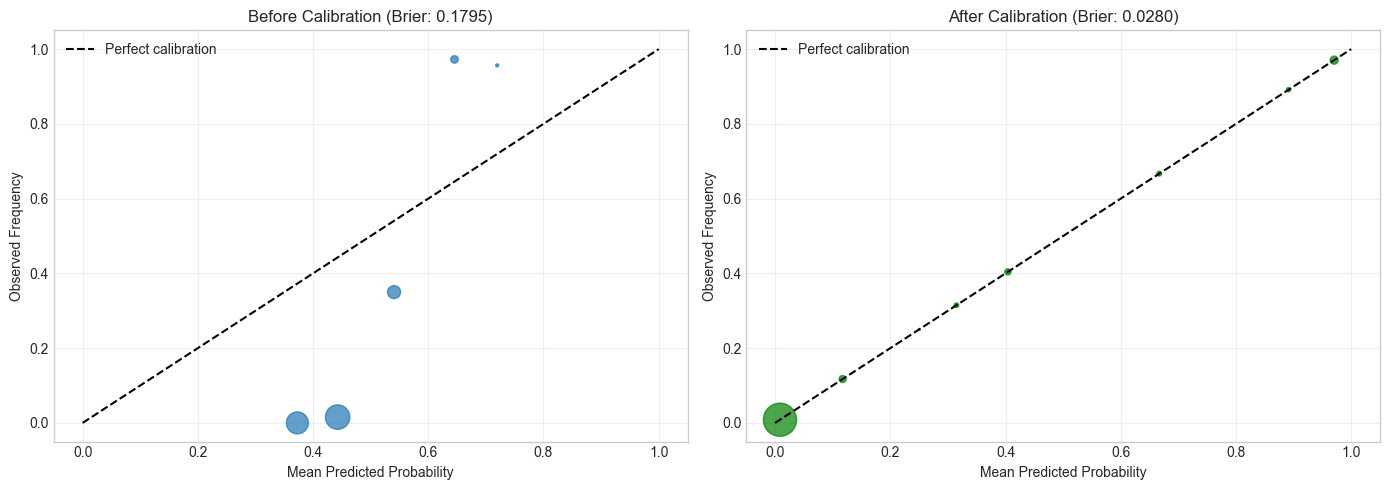

Calibration diagram saved to outputs/calibration_diagram.png


In [10]:
# Reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration
bin_means_before, observed_freqs_before, bin_counts_before = calibrator.get_reliability_data(raw_proba, val_binary)
ax = axes[0]
valid = ~np.isnan(bin_means_before)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.scatter(bin_means_before[valid], observed_freqs_before[valid], s=bin_counts_before[valid]/5, alpha=0.7)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Frequency')
ax.set_title(f'Before Calibration (Brier: {calibrator.brier_score_before:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# After calibration
bin_means_after, observed_freqs_after, bin_counts_after = calibrator.get_reliability_data(calibrated_proba, val_binary)
ax = axes[1]
valid = ~np.isnan(bin_means_after)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.scatter(bin_means_after[valid], observed_freqs_after[valid], s=bin_counts_after[valid]/5, alpha=0.7, color='green')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Frequency')
ax.set_title(f'After Calibration (Brier: {calibrator.brier_score_after:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration_diagram.png', dpi=150)
plt.show()

print(f"Calibration diagram saved to {OUTPUT_DIR / 'calibration_diagram.png'}")

## 4. Business Tier Classification

Convert predictions to executive-friendly tier labels with associated actions.

In [11]:
class TierClassifier:
    """
    Classifies sites into business tiers based on calibrated probabilities.
    Provides executive-friendly labels and recommended actions.
    """
    
    TIER_DEFINITIONS = {
        1: {
            'threshold': 0.75,
            'label': 'Tier 1 - Premium',
            'action': 'Invest: High priority for expansion and premium pricing',
            'confidence': 'High confidence top performer',
        },
        2: {
            'threshold': 0.50,
            'label': 'Tier 2 - Strong',
            'action': 'Optimize: Good performer with growth potential',
            'confidence': 'Likely above average',
        },
        3: {
            'threshold': 0.25,
            'label': 'Tier 3 - Standard',
            'action': 'Monitor: Average performance, watch for changes',
            'confidence': 'Performance uncertain',
        },
        4: {
            'threshold': 0.0,
            'label': 'Tier 4 - Review',
            'action': 'Flag: Below average, consider intervention or exit',
            'confidence': 'Likely underperformer',
        },
    }
    
    def classify(self, probability):
        """Classify a single probability into a tier."""
        for tier_num in [1, 2, 3, 4]:
            if probability >= self.TIER_DEFINITIONS[tier_num]['threshold']:
                tier = self.TIER_DEFINITIONS[tier_num]
                return {
                    'tier': tier_num,
                    'label': tier['label'],
                    'action': tier['action'],
                    'confidence': tier['confidence'],
                    'probability': probability,
                }
        return self.classify(0.0)  # Default to Tier 4
    
    def classify_batch(self, probabilities):
        """Classify multiple probabilities."""
        return [self.classify(p) for p in probabilities]
    
    def get_tier_distribution(self, probabilities):
        """Get distribution of tiers."""
        results = self.classify_batch(probabilities)
        distribution = {1: 0, 2: 0, 3: 0, 4: 0}
        for r in results:
            distribution[r['tier']] += 1
        return distribution

# Create tier classifier
tier_classifier = TierClassifier()

# Classify validation set
tier_results = tier_classifier.classify_batch(calibrated_proba)
tier_distribution = tier_classifier.get_tier_distribution(calibrated_proba)

print("Tier Distribution:")
print("=" * 50)
for tier_num, count in tier_distribution.items():
    pct = count / len(calibrated_proba) * 100
    tier_info = TierClassifier.TIER_DEFINITIONS[tier_num]
    print(f"  {tier_info['label']}: {count:,} ({pct:.1f}%)")

Tier Distribution:
  Tier 1 - Premium: 215 (6.3%)
  Tier 2 - Strong: 59 (1.7%)
  Tier 3 - Standard: 161 (4.7%)
  Tier 4 - Review: 2,978 (87.3%)


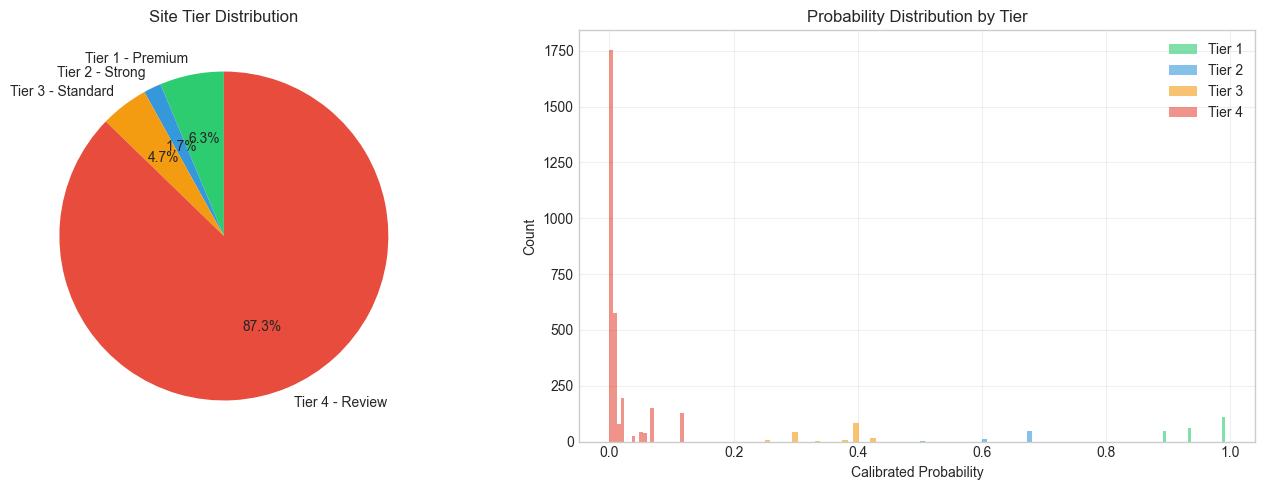

In [12]:
# Visualize tier distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax = axes[0]
labels = [TierClassifier.TIER_DEFINITIONS[i]['label'] for i in [1, 2, 3, 4]]
sizes = [tier_distribution[i] for i in [1, 2, 3, 4]]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Site Tier Distribution')

# Probability histogram by tier
ax = axes[1]
tier_labels = [r['tier'] for r in tier_results]
for tier_num in [1, 2, 3, 4]:
    tier_proba = [p for p, t in zip(calibrated_proba, tier_labels) if t == tier_num]
    if tier_proba:
        ax.hist(tier_proba, bins=20, alpha=0.6, label=f'Tier {tier_num}', color=colors[tier_num-1])
ax.set_xlabel('Calibrated Probability')
ax.set_ylabel('Count')
ax.set_title('Probability Distribution by Tier')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tier_distribution.png', dpi=150)
plt.show()

## 5. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) provides interpretable feature importance by computing each feature's contribution to the prediction.

In [13]:
if SHAP_AVAILABLE:
    # Sample background data for SHAP (use subset for efficiency)
    n_background = min(100, len(val_X))
    background_idx = np.random.choice(len(val_X), n_background, replace=False)
    background_data = val_X[background_idx]
    
    print(f"Using {n_background} background samples for SHAP")
    
    # Create SHAP explainer
    # Use predict_regression for continuous output
    explainer = shap.KernelExplainer(
        sklearn_wrapper.predict_regression,
        background_data,
    )
    
    print("SHAP explainer created")
else:
    print("SHAP not available. Skipping feature importance analysis.")

Using 100 background samples for SHAP
SHAP explainer created


In [14]:
if SHAP_AVAILABLE:
    # Compute SHAP values for a sample of test data
    n_explain = 50  # Number of samples to explain
    explain_idx = np.random.choice(len(val_X), n_explain, replace=False)
    explain_data = val_X[explain_idx]
    
    print(f"Computing SHAP values for {n_explain} samples (this may take a few minutes)...")
    shap_values = explainer.shap_values(explain_data, nsamples=50)
    
    print(f"SHAP values shape: {shap_values.shape}")
else:
    shap_values = None

Computing SHAP values for 50 samples (this may take a few minutes)...


  2%|▏         | 1/50 [00:01<00:59,  1.21s/it]/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=7.684e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=3.842e-03, with an active set of 2 regressors, and the smallest cholesky pivot element being 6.664e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in acti

SHAP values shape: (50, 60)


In [15]:
# Create feature names
feature_names = (
    preprocessor.get('available_numeric', [f'numeric_{i}' for i in range(config['n_numeric'])]) +
    list(config['categorical_vocab_sizes'].keys()) +
    preprocessor.get('available_boolean', [f'boolean_{i}' for i in range(config['n_boolean'])])
)

print(f"Total features: {len(feature_names)}")
print(f"  Numeric: {config['n_numeric']}")
print(f"  Categorical: {len(config['categorical_vocab_sizes'])}")
print(f"  Boolean: {config['n_boolean']}")

Total features: 60
  Numeric: 11
  Categorical: 9
  Boolean: 40


In [16]:
if SHAP_AVAILABLE and shap_values is not None:
    # Calculate mean absolute SHAP values for feature importance
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    # Create feature importance DataFrame
    feature_importance = pd.DataFrame({
        'feature': feature_names[:len(mean_abs_shap)],
        'importance': mean_abs_shap,
    }).sort_values('importance', ascending=False)
    
    print("Top 20 Most Important Features:")
    print("=" * 50)
    for i, (_, row) in enumerate(feature_importance.head(20).iterrows()):
        bar = '█' * int(row['importance'] / feature_importance['importance'].max() * 20)
        print(f"{i+1:2}. {row['feature']:35} {row['importance']:.4f} {bar}")

Top 20 Most Important Features:
 1. log_total_revenue                   0.1878 ████████████████████
 2. rs_Impressions                      0.0219 ██
 3. rs_Revenue                          0.0099 █
 4. rs_NVIs                             0.0094 
 5. c_open_24_hours_encoded             0.0080 
 6. pct_female                          0.0061 
 7. r_recruitment_encoded               0.0056 
 8. median_age                          0.0056 
 9. log_nearest_site_distance_mi        0.0055 
10. log_min_distance_to_interstate_mi   0.0049 
11. r_cpg_cbd_hemp_ingestibles_non_thc_encoded 0.0047 
12. c_sells_beer_encoded                0.0045 
13. avg_household_income                0.0043 
14. rs_RevenuePerScreen                 0.0043 
15. c_sells_wine_encoded                0.0039 
16. c_nfc_enabled_encoded               0.0038 
17. r_government_political_encoded      0.0038 
18. c_vistar_programmatic_enabled_encoded 0.0033 
19. brand_c_store                       0.0032 
20. r_retail_grocerty_wi

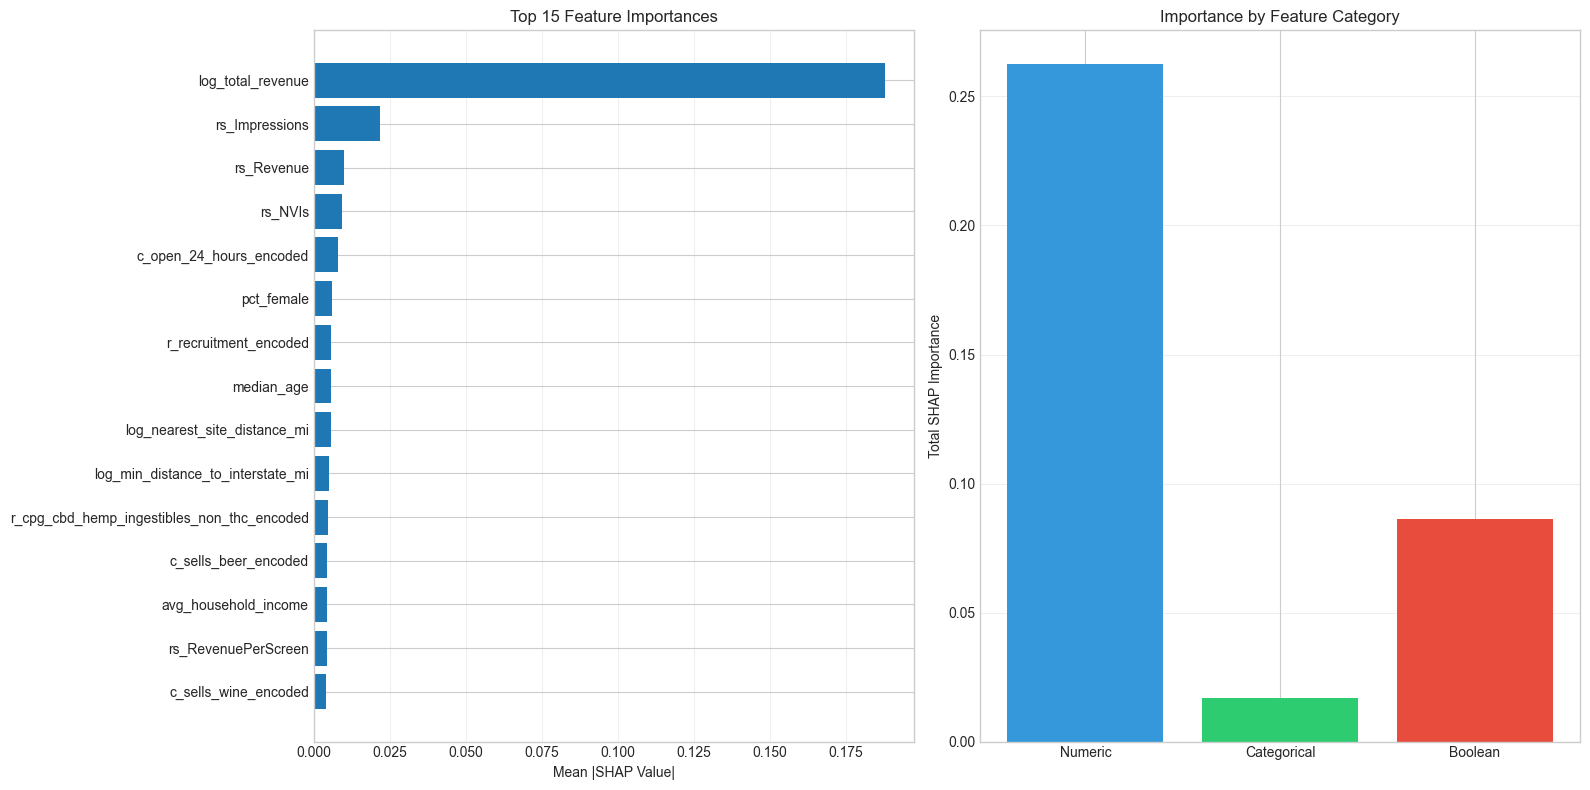

SHAP importance plot saved to outputs/shap_importance.png


In [17]:
if SHAP_AVAILABLE and shap_values is not None:
    # SHAP summary plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar plot of top features
    ax = axes[0]
    top_features = feature_importance.head(15)
    ax.barh(range(len(top_features)), top_features['importance'].values[::-1])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values[::-1])
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title('Top 15 Feature Importances')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Feature importance by category
    ax = axes[1]
    categories = {
        'Numeric': feature_importance[feature_importance['feature'].isin(preprocessor.get('available_numeric', []))]['importance'].sum(),
        'Categorical': feature_importance[feature_importance['feature'].isin(list(config['categorical_vocab_sizes'].keys()))]['importance'].sum(),
        'Boolean': feature_importance[feature_importance['feature'].isin(preprocessor.get('available_boolean', []))]['importance'].sum(),
    }
    ax.bar(categories.keys(), categories.values(), color=['#3498db', '#2ecc71', '#e74c3c'])
    ax.set_ylabel('Total SHAP Importance')
    ax.set_title('Importance by Feature Category')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_importance.png', dpi=150)
    plt.show()
    
    print(f"SHAP importance plot saved to {OUTPUT_DIR / 'shap_importance.png'}")

## 6. Example Site Explanation

In [18]:
def explain_site(site_idx, X, shap_values, feature_names, tier_classifier, calibrated_proba, target_scaler, preprocessor):
    """
    Generate a comprehensive explanation for a single site.
    """
    # Get site SHAP values
    site_shap = shap_values[site_idx] if shap_values is not None else np.zeros(len(feature_names))
    
    # Get tier classification
    tier_result = tier_classifier.classify(calibrated_proba[site_idx])
    
    # Get top positive and negative drivers
    feature_impacts = list(zip(feature_names[:len(site_shap)], site_shap))
    positive_drivers = sorted([f for f in feature_impacts if f[1] > 0], key=lambda x: x[1], reverse=True)[:5]
    negative_drivers = sorted([f for f in feature_impacts if f[1] < 0], key=lambda x: x[1])[:5]
    
    # Print explanation
    print("=" * 60)
    print(f"SITE EXPLANATION - Sample #{site_idx}")
    print("=" * 60)
    print(f"\nClassification: {tier_result['label']}")
    print(f"Confidence: {tier_result['confidence']}")
    print(f"Probability: {tier_result['probability']:.2%}")
    print(f"\nRecommendation: {tier_result['action']}")
    
    if shap_values is not None:
        print(f"\nKey Strengths:")
        for feature, impact in positive_drivers:
            print(f"  + {feature}: +{impact:.4f}")
        
        print(f"\nAreas for Improvement:")
        for feature, impact in negative_drivers:
            print(f"  - {feature}: {impact:.4f}")
    
    return {
        'tier': tier_result,
        'positive_drivers': positive_drivers,
        'negative_drivers': negative_drivers,
    }

# Explain a few sample sites
if SHAP_AVAILABLE and shap_values is not None:
    for idx in [0, 25, 49]:
        explain_site(idx, explain_data, shap_values, feature_names, 
                     tier_classifier, calibrated_proba[explain_idx], 
                     target_scaler, preprocessor)
        print()

SITE EXPLANATION - Sample #0

Classification: Tier 4 - Review
Confidence: Likely underperformer
Probability: 0.00%

Recommendation: Flag: Below average, consider intervention or exit

Key Strengths:
  + c_nfc_enabled_encoded: +0.0045

Areas for Improvement:
  - log_total_revenue: -0.0809
  - r_cpg_non_food_beverage_cannabis_medical_encoded: -0.0268
  - c_emv_enabled_encoded: -0.0119
  - r_government_political_encoded: -0.0113
  - avg_household_income: -0.0107

SITE EXPLANATION - Sample #25

Classification: Tier 4 - Review
Confidence: Likely underperformer
Probability: 0.69%

Recommendation: Flag: Below average, consider intervention or exit

Key Strengths:
  + rs_Revenue: +0.0335
  + network: +0.0234
  + brand_restaurant: +0.0180
  + r_cpg_beverage_spirits_video_encoded: +0.0112
  + c_walk_up_enabled_encoded: +0.0059

Areas for Improvement:
  - log_total_revenue: -0.0855
  - r_cpg_non_food_beverage_cannabis_recreational_encoded: -0.0272
  - r_associations_and_npo_anti_smoking_encoded: 

## 7. Save Explainability Artifacts

In [19]:
# Save calibrator
with open(OUTPUT_DIR / 'calibrator.pkl', 'wb') as f:
    pickle.dump({
        'calibrator': calibrator.calibrator,
        'brier_score_before': calibrator.brier_score_before,
        'brier_score_after': calibrator.brier_score_after,
    }, f)

print(f"Calibrator saved to {OUTPUT_DIR / 'calibrator.pkl'}")

# Save tier classifier configuration
with open(OUTPUT_DIR / 'tier_classifier.json', 'w') as f:
    json.dump(TierClassifier.TIER_DEFINITIONS, f, indent=2)

print(f"Tier classifier config saved to {OUTPUT_DIR / 'tier_classifier.json'}")

# Save feature importance
if SHAP_AVAILABLE and shap_values is not None:
    feature_importance.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
    print(f"Feature importance saved to {OUTPUT_DIR / 'feature_importance.csv'}")

Calibrator saved to outputs/calibrator.pkl
Tier classifier config saved to outputs/tier_classifier.json
Feature importance saved to outputs/feature_importance.csv


In [20]:
# Save explainability summary
explainability_summary = {
    'calibration': {
        'method': 'isotonic',
        'brier_score_before': float(calibrator.brier_score_before),
        'brier_score_after': float(calibrator.brier_score_after),
        'improvement_pct': float((calibrator.brier_score_before - calibrator.brier_score_after) / calibrator.brier_score_before * 100),
    },
    'tier_distribution': {str(k): v for k, v in tier_distribution.items()},
    'shap_available': SHAP_AVAILABLE,
    'n_features': len(feature_names),
}

if SHAP_AVAILABLE and shap_values is not None:
    explainability_summary['top_5_features'] = feature_importance.head(5)['feature'].tolist()

with open(OUTPUT_DIR / 'explainability_summary.json', 'w') as f:
    json.dump(explainability_summary, f, indent=2)

print(f"Explainability summary saved to {OUTPUT_DIR / 'explainability_summary.json'}")

Explainability summary saved to outputs/explainability_summary.json


---

## Summary

This notebook has:
1. ✅ Created sklearn-compatible model wrapper
2. ✅ Implemented probability calibration with isotonic regression
3. ✅ Built business tier classification (Tier 1-4)
4. ✅ Computed SHAP feature importance (if SHAP installed)
5. ✅ Generated individual site explanations
6. ✅ Saved explainability artifacts

**Artifacts created:**
- `outputs/calibrator.pkl` - Probability calibrator
- `outputs/tier_classifier.json` - Tier definitions
- `outputs/feature_importance.csv` - SHAP feature importance
- `outputs/calibration_diagram.png` - Calibration visualization
- `outputs/tier_distribution.png` - Tier distribution
- `outputs/shap_importance.png` - SHAP importance plot
- `outputs/explainability_summary.json` - Summary statistics

## Complete Notebook Series

You have now completed all 6 notebooks:

1. **01_data_loading_exploration.ipynb** - Data loading and EDA
2. **02_data_preprocessing.ipynb** - Feature engineering and preprocessing
3. **03_model_training.ipynb** - Model architecture and training
4. **04_evaluation_inference.ipynb** - Evaluation and inference
5. **05_model_comparison.ipynb** - XGBoost vs Neural Network comparison
6. **06_explainability.ipynb** - Calibration, tiers, and SHAP

These notebooks can be run sequentially in SageMaker for model testing and experimentation.